In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('C_call_volume.csv')
df.head()

,event_id,node_id,source_id,target_id,direction,start_time,connect_time,end_time,duration_sec,billed_seconds,call_result,cost
0,EVT000027716,node_7,9XXXXX75,9XXXXX04,inbound,2026-04-29 17:18:11 UTC,NaN,NaN,0,0,no_answer,0.00
1,EVT000029216,node_7,9XXXXX03,9XXXXX51,outbound,2026-05-02 07:54:36,NaN,NaN,0,0,no_answer,0.00
2,EVT000041506,node_3,9XXXXX70,9XXXXX19,inbound,2026-05-25 15:57:20,NaN,NaN,0,0,no_answer,0.00
3,EVT000005987,node_5,9XXXXX68,9XXXXX66,outbound,2026-03-16 20:58:39,2026-03-16 20:59:05,2026-03-16 21:00:32,87,87,answered,30.60
4,EVT000010513,node_8,9XXXXX64,9XXXXX46,outbound,2026-03-25 11:25:21 UTC,2026-03-25 11:25:43,2026-03-25 11:29:02,199,199,answered,74.17


In [4]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df.set_index('start_time', inplace=True)
df.head()

,event_id,node_id,source_id,target_id,direction,connect_time,end_time,duration_sec,billed_seconds,call_result,cost
start_time,,,,,,,,,,,
2026-04-29 17:18:11+00:00,EVT000027716,node_7,9XXXXX75,9XXXXX04,inbound,NaN,NaN,0,0,no_answer,0.00
NaT,EVT000029216,node_7,9XXXXX03,9XXXXX51,outbound,NaN,NaN,0,0,no_answer,0.00
NaT,EVT000041506,node_3,9XXXXX70,9XXXXX19,inbound,NaN,NaN,0,0,no_answer,0.00
NaT,EVT000005987,node_5,9XXXXX68,9XXXXX66,outbound,2026-03-16 20:59:05,2026-03-16 21:00:32,87,87,answered,30.60
2026-03-25 11:25:21+00:00,EVT000010513,node_8,9XXXXX64,9XXXXX46,outbound,2026-03-25 11:25:43,2026-03-25 11:29:02,199,199,answered,74.17


In [5]:
daily_calls = df['event_id'].resample('D').count()
print("Өдөр тутмын дуудлагын тоо")
print(daily_calls.head(10))

Өдөр тутмын дуудлагын тоо
start_time
2026-03-03 00:00:00+00:00    12
2026-03-04 00:00:00+00:00    20
2026-03-05 00:00:00+00:00    11
2026-03-06 00:00:00+00:00    15
2026-03-07 00:00:00+00:00     8
2026-03-08 00:00:00+00:00    11
2026-03-09 00:00:00+00:00    16
2026-03-10 00:00:00+00:00    16
2026-03-11 00:00:00+00:00     6
2026-03-12 00:00:00+00:00    16
Name: event_id, dtype: int64


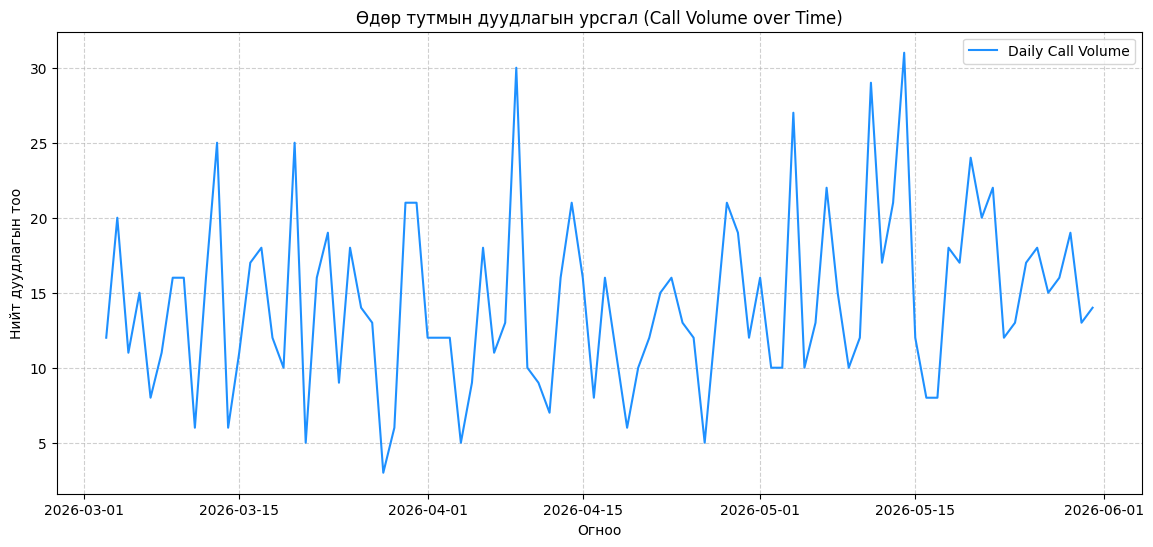

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(daily_calls.index, daily_calls.values, label='Daily Call Volume', color='dodgerblue', linewidth=1.5)
plt.title('Өдөр тутмын дуудлагын урсгал (Call Volume over Time)')
plt.xlabel('Огноо')
plt.ylabel('Нийт дуудлагын тоо')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
df_day = daily_calls.to_frame(name='call_count')
df_day['day_of_week'] = df_day.index.dayofweek
df_day['day_of_month'] = df_day.index.day
df_day['is_weekend'] = df_day['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df_day.head(10)

,call_count,day_of_week,day_of_month,is_weekend
start_time,,,,
2026-03-03 00:00:00+00:00,12,1,3,0
2026-03-04 00:00:00+00:00,20,2,4,0
2026-03-05 00:00:00+00:00,11,3,5,0
2026-03-06 00:00:00+00:00,15,4,6,0
2026-03-07 00:00:00+00:00,8,5,7,1
2026-03-08 00:00:00+00:00,11,6,8,1
2026-03-09 00:00:00+00:00,16,0,9,0
2026-03-10 00:00:00+00:00,16,1,10,0
2026-03-11 00:00:00+00:00,6,2,11,0


In [8]:
test_days = 15
train_data = df_day.iloc[:-test_days]
test_data = df_day.iloc[-test_days:]
print(f"Сургалтын датаны хэмжээ (Train): {train_data.shape[0]} өдөр")
print(f"Шалгалтын датаны хэмжээ (Test): {test_data.shape[0]} өдөр")

Сургалтын датаны хэмжээ (Train): 75 өдөр
Шалгалтын датаны хэмжээ (Test): 15 өдөр


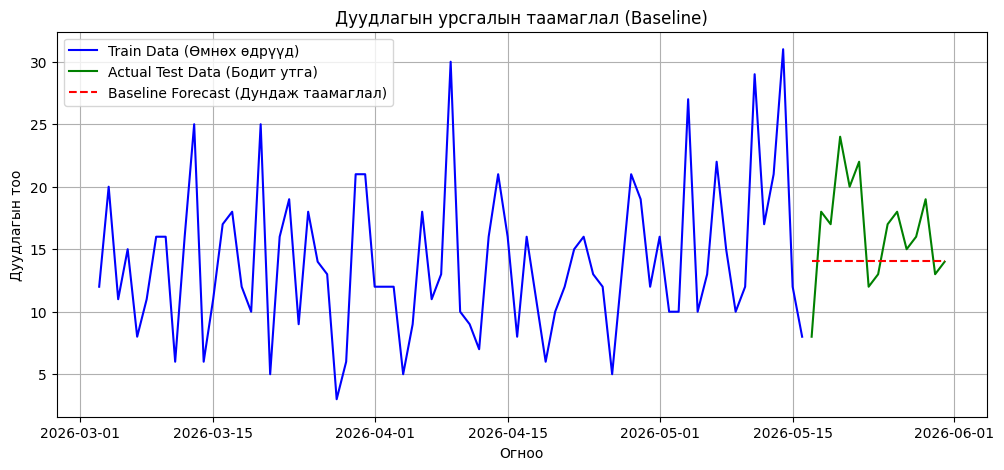

In [9]:
baseline_forecast = train_data['call_count'].mean()
test_data = test_data.copy()
test_data['baseline_pred'] = baseline_forecast
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['call_count'], label='Train Data (Өмнөх өдрүүд)', color='blue')
plt.plot(test_data.index, test_data['call_count'], label='Actual Test Data (Бодит утга)', color='green')
plt.plot(test_data.index, test_data['baseline_pred'], label='Baseline Forecast (Дундаж таамаглал)', color='red', linestyle='--')
plt.title('Дуудлагын урсгалын таамаглал (Baseline)')
plt.xlabel('Огноо')
plt.ylabel('Дуудлагын тоо')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
features = ['day_of_week', 'day_of_month', 'is_weekend']
X_train = train_data[features]
y_train = train_data['call_count']
X_test = test_data[features]
y_test = test_data['call_count']
model = LinearRegression()
model.fit(X_train, y_train)
test_data = test_data.copy()
test_data['ml_pred'] = model.predict(X_test)
mae = mean_absolute_error(y_test, test_data['ml_pred'])
print(f"Моделийн дундаж алдаа (MAE): {mae:.2f} дуудлага")

Моделийн дундаж алдаа (MAE): 3.07 дуудлага


In [11]:
!pip install scikit-learn


     |████████████████████████████████| 11.1 MB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 2.0 MB/s eta 0:00:01
You should consider upgrading via the '/Users/bat-orgilkhashbat/Desktop/data-science-internship-practice/student-C/venv/bin/python3 -m pip install --upgrade pip' command.


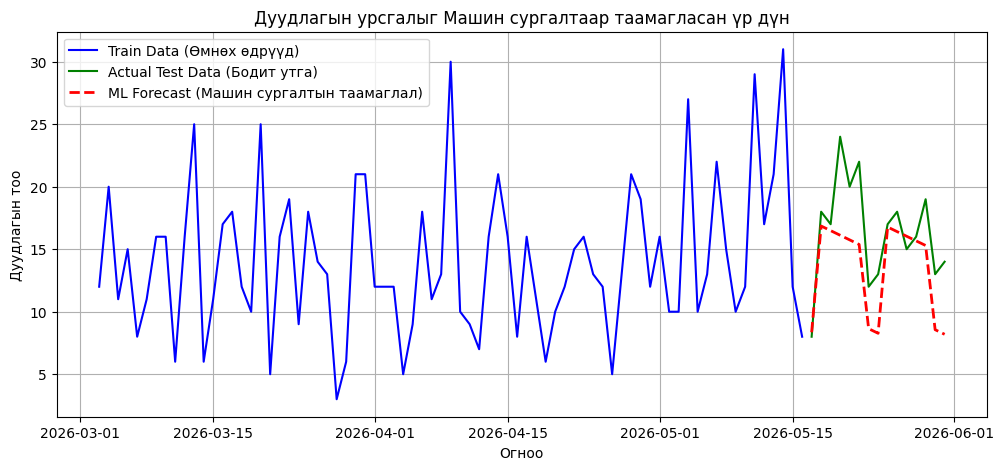

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['call_count'], label='Train Data (Өмнөх өдрүүд)', color='blue')
plt.plot(test_data.index, test_data['call_count'], label='Actual Test Data (Бодит утга)', color='green')
plt.plot(test_data.index, test_data['ml_pred'], label='ML Forecast (Машин сургалтын таамаглал)', color='red', linestyle='--', linewidth=2)
plt.title('Дуудлагын урсгалыг Машин сургалтаар таамагласан үр дүн')
plt.xlabel('Огноо')
plt.ylabel('Дуудлагын тоо')
plt.legend()
plt.grid(True)
plt.show()